# 🎯 L'objectif de ce notebook est de préparer et explorer une base de donnée sur les voitures d'occasion américaines dans un but de pouvoir estimer le prix `Price`. On effectuera :
- 1 - EDA(graphiques, values counts...)
- 2 - Preprocessing
- 3 - Feature engineering

La préparation des données est une étape fondamentale dans un projet de Machine Learning. La qualité des différents modèles et leurs performances dépend énormément de cette étape. Ainsi, il est primordiale de bien explorer les données à disposition, traiter les anomalies, créer de nouvelles variables plus consequente... C'est donc les concepts que ce Notebook va illustrer.

Source des données utilisée :
- https://www.kaggle.com/datasets/ananaymital/us-used-cars-dataset

## Importation des bibliothèques nécéssaire

In [212]:
from unittest.mock import inplace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

## Problematique

Comme évoqué en introduction, la préparation des données d'entrainement n'est pas une étape à négliger, elle aura un énorme impact sur la capacité d'un modèle prédictif à généraliser, il faudra ainsi gérer :

- Les valeurs manquantes qui limitent la représentativité des données
- Les outliers qui biaisent les prédictions
- Les variables numériques et/ou catégorielles qui peuvent influencer la performance des algorithmes de prédiction

## Importation des données

Nous allons utiliser des données sur les voitures d'occasion américaines. L'ensemble de données contient les détails de 3 millions de voitures d'occasion réelles. Ainsi, afin de faciliter les processus, nous allons réduire le nombre d'observations. Puis, nous allons séparer les données avant l'exploration, en ensemble d'entraînement et de test.

In [2]:
main_path = "/Users/z/Desktop/cours_machinelearning"
cars_path = main_path + "/used_cars_data.csv"
print(cars_path)
df = pd.read_csv(cars_path, sep=",")

/Users/z/Desktop/cours_machinelearning/used_cars_data.csv


/var/folders/mc/g9__gqz90s7dx6wyrgy5rfbw0000gn/T/ipykernel_29899/2751648494.py:4: DtypeWarning: Columns (0: dealer_zip) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cars_path, sep=",")


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 66 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   vin                      str    
 1   back_legroom             str    
 2   bed                      str    
 3   bed_height               str    
 4   bed_length               str    
 5   body_type                str    
 6   cabin                    str    
 7   city                     str    
 8   city_fuel_economy        float64
 9   combine_fuel_economy     float64
 10  daysonmarket             int64  
 11  dealer_zip               object 
 12  description              str    
 13  engine_cylinders         str    
 14  engine_displacement      float64
 15  engine_type              str    
 16  exterior_color           str    
 17  fleet                    object 
 18  frame_damaged            object 
 19  franchise_dealer         bool   
 20  franchise_make           str    
 21  front_legroom      

## Filtres pour homogeneiser et fiabiliser les données

In [4]:
df = df[df["bed"].isna()]
df = df[df["cabin"].isna()]
df = df[df["frame_damaged"] != True]
df = df[df["has_accidents"] != True]
df = df[df["isCab"] != True]
df = df[~df["main_picture_url"].isna()]
df = df[(df["owner_count"].isna()) | (df["owner_count"] == 1)]
df = df[df["salvage"] != True]
df = df[df["theft_title"] != True]
df = df[df["daysonmarket"] < 365]

## Supression de certaines colonnes

In [6]:
df = df.drop(["bed", "bed_height", "cabin", "city", "dealer_zip",
              "description", "exterior_color", "has_accidents", "interior_color",
              "isCab", "frame_damaged", "latitude", "longitude", "main_picture_url", "owner_count",
              "is_certified", "is_cpo", "salvage", "savings_amount", "seller_rating", "sp_id", "theft_title",
              "vehicle_damage_category"], axis=1)

In [7]:
df.info() #42 colonnes

<class 'pandas.DataFrame'>
Index: 1814329 entries, 1 to 3000039
Data columns (total 43 columns):
 #   Column                Dtype  
---  ------                -----  
 0   vin                   str    
 1   back_legroom          str    
 2   bed_length            str    
 3   body_type             str    
 4   city_fuel_economy     float64
 5   combine_fuel_economy  float64
 6   daysonmarket          int64  
 7   engine_cylinders      str    
 8   engine_displacement   float64
 9   engine_type           str    
 10  fleet                 object 
 11  franchise_dealer      bool   
 12  franchise_make        str    
 13  front_legroom         str    
 14  fuel_tank_volume      str    
 15  fuel_type             str    
 16  height                str    
 17  highway_fuel_economy  float64
 18  horsepower            float64
 19  is_new                bool   
 20  is_oemcpo             object 
 21  length                str    
 22  listed_date           str    
 23  listing_color         s

## Suppression 50% du dadaframe pour accélérer le read les prochaines fois sur read_csv

In [9]:
df #1814329 rows × 43 columns

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
1,SALCJ2FX1LH858117,38.1 in,NaN,SUV / Crossover,NaN,NaN,207,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALRR2RV0L2433391,37.6 in,NaN,SUV / Crossover,NaN,NaN,196,V6,3000.0,V6,...,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,SUV / Crossover,NaN,NaN,137,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
5,SALYK2EX1LA261711,37.1 in,NaN,SUV / Crossover,NaN,NaN,242,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
7,SALYK2EX5LA275434,37.1 in,NaN,SUV / Crossover,NaN,NaN,70,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000032,3N6CM0KNXLK704386,--,NaN,Van,24.0,NaN,62,I4,2000.0,I4,...,"139 lb-ft @ 4,800 RPM",CVT,Continuously Variable Transmission,t88980,S FWD,FWD,Front-Wheel Drive,115.2 in,68.1 in,2020
3000033,JTDKB20U363142125,38.6 in,NaN,Hatchback,48.0,NaN,218,I4 Hybrid,1500.0,I4 Hybrid,...,NaN,CVT,Continuously Variable Transmission,t12219,FWD,FWD,Front-Wheel Drive,106.3 in,67.9 in,2006
3000036,1GNERFKW0LJ225508,38.4 in,NaN,SUV / Crossover,18.0,NaN,171,V6,3600.0,V6,...,"266 lb-ft @ 2,800 RPM",A,Automatic,t85763,LS FWD,FWD,Front-Wheel Drive,120.9 in,78.6 in,2020
3000038,SAJAJ4BNXHA968809,35 in,NaN,Sedan,30.0,NaN,11,I4 Diesel,2000.0,I4 Diesel,...,"318 lb-ft @ 1,750 RPM",A,Automatic,t65977,20d Premium AWD,AWD,All-Wheel Drive,111.6 in,81.7 in,2017


In [10]:
df = df.iloc[:len(df)//2] #Garde 50% du dataframe (Les premières lignes représentant 50% de df)

In [11]:
df

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
1,SALCJ2FX1LH858117,38.1 in,NaN,SUV / Crossover,NaN,NaN,207,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALRR2RV0L2433391,37.6 in,NaN,SUV / Crossover,NaN,NaN,196,V6,3000.0,V6,...,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,SUV / Crossover,NaN,NaN,137,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
5,SALYK2EX1LA261711,37.1 in,NaN,SUV / Crossover,NaN,NaN,242,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
7,SALYK2EX5LA275434,37.1 in,NaN,SUV / Crossover,NaN,NaN,70,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1491477,JM3KFADM5L0849885,39.6 in,NaN,SUV / Crossover,25.0,NaN,7,I4,2500.0,I4,...,"186 lb-ft @ 4,000 RPM",A,6-Speed Automatic,t89612,Grand Touring FWD,FWD,Front-Wheel Drive,106.2 in,83.3 in,2020
1491479,3TYRX5GN3LT003014,NaN,NaN,Pickup Truck,NaN,NaN,23,I4,NaN,I4,...,NaN,A,6-Speed Automatic,NaN,NaN,NaN,NaN,NaN,NaN,2020
1491482,2T3H1RFV5LC073809,37.8 in,NaN,SUV / Crossover,27.0,NaN,40,I4,2500.0,I4,...,NaN,A,8-Speed Automatic,t89228,LE FWD,FWD,Front-Wheel Drive,105.9 in,73 in,2020
1491483,3TYRX5GN2LT003134,NaN,NaN,Pickup Truck,NaN,NaN,23,I4,NaN,I4,...,NaN,A,6-Speed Automatic,NaN,NaN,NaN,NaN,NaN,NaN,2020


In [12]:
csv_path = main_path + "/used_cars_data_short.csv"
df.to_csv(csv_path, index=False)

## Désormais on va travailler sur _used_cars_data_short.csv qui a moins d'observation

In [13]:
df2=pd.read_csv(csv_path, sep=",")
df2

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
0,SALCJ2FX1LH858117,38.1 in,NaN,SUV / Crossover,NaN,NaN,207,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
1,SALRR2RV0L2433391,37.6 in,NaN,SUV / Crossover,NaN,NaN,196,V6,3000.0,V6,...,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,AWD,All-Wheel Drive,115 in,87.4 in,2020
2,SALCJ2FXXLH862327,38.1 in,NaN,SUV / Crossover,NaN,NaN,137,I4,2000.0,I4,...,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
3,SALYK2EX1LA261711,37.1 in,NaN,SUV / Crossover,NaN,NaN,242,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
4,SALYK2EX5LA275434,37.1 in,NaN,SUV / Crossover,NaN,NaN,70,I4,2000.0,I4,...,"269 lb-ft @ 1,200 RPM",A,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,AWD,All-Wheel Drive,113.1 in,84.4 in,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907159,JM3KFADM5L0849885,39.6 in,NaN,SUV / Crossover,25.0,NaN,7,I4,2500.0,I4,...,"186 lb-ft @ 4,000 RPM",A,6-Speed Automatic,t89612,Grand Touring FWD,FWD,Front-Wheel Drive,106.2 in,83.3 in,2020
907160,3TYRX5GN3LT003014,NaN,NaN,Pickup Truck,NaN,NaN,23,I4,NaN,I4,...,NaN,A,6-Speed Automatic,NaN,NaN,NaN,NaN,NaN,NaN,2020
907161,2T3H1RFV5LC073809,37.8 in,NaN,SUV / Crossover,27.0,NaN,40,I4,2500.0,I4,...,NaN,A,8-Speed Automatic,t89228,LE FWD,FWD,Front-Wheel Drive,105.9 in,73 in,2020
907162,3TYRX5GN2LT003134,NaN,NaN,Pickup Truck,NaN,NaN,23,I4,NaN,I4,...,NaN,A,6-Speed Automatic,NaN,NaN,NaN,NaN,NaN,NaN,2020


## On créer un ensemble de donnée d'entrainement et un ensemble de test à l'aide de Scikit-learn

In [14]:
SEED=32
df_train, df_test=train_test_split(df2, test_size=0.2, random_state=SEED)

# Analyses exploratoires - EDA

### Dictionnaire des variables

In [15]:
df_train.info()

<class 'pandas.DataFrame'>
Index: 725731 entries, 53223 to 10967
Data columns (total 43 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   725731 non-null  str    
 1   back_legroom          692165 non-null  str    
 2   bed_length            96403 non-null   str    
 3   body_type             721996 non-null  str    
 4   city_fuel_economy     614491 non-null  float64
 5   combine_fuel_economy  0 non-null       float64
 6   daysonmarket          725731 non-null  int64  
 7   engine_cylinders      705427 non-null  str    
 8   engine_displacement   687240 non-null  float64
 9   engine_type           705427 non-null  str    
 10  fleet                 284276 non-null  object 
 11  franchise_dealer      725731 non-null  bool   
 12  franchise_make        661530 non-null  str    
 13  front_legroom         692165 non-null  str    
 14  fuel_tank_volume      692165 non-null  str    
 15  fuel_type    

### Description des données

In [16]:
df_train.head()

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,torque,transmission,transmission_display,trimId,trim_name,wheel_system,wheel_system_display,wheelbase,width,year
53223,1GNSKAKC5KR408631,39 in,NaN,SUV / Crossover,NaN,NaN,13,V8,5300.0,V8,...,"383 lb-ft @ 4,100 RPM",A,6-Speed Automatic Overdrive,t80469,LS 4WD,4WD,Four-Wheel Drive,116 in,80.5 in,2019
161217,JTMA1RFV5LD531197,37.8 in,NaN,SUV / Crossover,25.0,NaN,11,I4,2500.0,I4,...,NaN,A,8-Speed Automatic,t89233,XLE Premium AWD,AWD,All-Wheel Drive,105.9 in,73 in,2020
661143,1C4RJFAG3LC437190,38.6 in,NaN,SUV / Crossover,18.0,NaN,4,V6,3600.0,V6,...,"260 lb-ft @ 4,000 RPM",A,Automatic,t87078,Altitude 4WD,4WD,Four-Wheel Drive,114.7 in,84.8 in,2020
114956,2T1BURHE4HC896404,41.4 in,NaN,Sedan,28.0,NaN,21,I4,1800.0,I4,...,"128 lb-ft @ 4,400 RPM",CVT,Continuously Variable Transmission,t68319,SE,FWD,Front-Wheel Drive,106.3 in,69.9 in,2017
341648,3GNCJPSB7LL302496,35.7 in,NaN,SUV / Crossover,24.0,NaN,61,I4,1400.0,I4,...,148 lb-ft @ 200 RPM,A,6-Speed Automatic,t85769,LT AWD,AWD,All-Wheel Drive,100.6 in,69.9 in,2020


In [17]:
df_train.info() #725731

<class 'pandas.DataFrame'>
Index: 725731 entries, 53223 to 10967
Data columns (total 43 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   725731 non-null  str    
 1   back_legroom          692165 non-null  str    
 2   bed_length            96403 non-null   str    
 3   body_type             721996 non-null  str    
 4   city_fuel_economy     614491 non-null  float64
 5   combine_fuel_economy  0 non-null       float64
 6   daysonmarket          725731 non-null  int64  
 7   engine_cylinders      705427 non-null  str    
 8   engine_displacement   687240 non-null  float64
 9   engine_type           705427 non-null  str    
 10  fleet                 284276 non-null  object 
 11  franchise_dealer      725731 non-null  bool   
 12  franchise_make        661530 non-null  str    
 13  front_legroom         692165 non-null  str    
 14  fuel_tank_volume      692165 non-null  str    
 15  fuel_type    

In [18]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 181433 entries, 22447 to 886202
Data columns (total 43 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   181433 non-null  str    
 1   back_legroom          173141 non-null  str    
 2   bed_length            24206 non-null   str    
 3   body_type             180515 non-null  str    
 4   city_fuel_economy     153728 non-null  float64
 5   combine_fuel_economy  0 non-null       float64
 6   daysonmarket          181433 non-null  int64  
 7   engine_cylinders      176385 non-null  str    
 8   engine_displacement   171893 non-null  float64
 9   engine_type           176385 non-null  str    
 10  fleet                 71200 non-null   object 
 11  franchise_dealer      181433 non-null  bool   
 12  franchise_make        165303 non-null  str    
 13  front_legroom         173141 non-null  str    
 14  fuel_tank_volume      173141 non-null  str    
 15  fuel_type   

### Valeur manquantes

Au total, on a pour les données d'entrainement 725731 observation et pour celle de test 181433. On remarque que pour certaines variables, il y'a trop de valeurs manquantes, ainsi ces variables ne sont soit pas exploitable soit devront etre imputé si c'est possible.

- `bed_length` : la majorité des valeurs de cette variable sont manquantes, elle n'est donc pas exploitable et devra être supprimée ;
- `combine_fuel_economy` : la majorité des valeurs de cette variable sont manquantes, elle n'est donc pas exploitable et devra être supprimée ;
- `fleet` : la majorité des valeurs de cette variable sont manquantes, elle n'est donc pas exploitable et devra être supprimée ;
- `is_oemcpo` : la majorité des valeurs de cette variable sont manquantes, elle n'est donc pas exploitable et devra être supprimée ;

Les autres variables ont une quantité de valeur manquante raisonnable. Si elles sont importantes, on pourra imputer les valeurs manquantes pour éviter de perdre les observations correspondantes.

### Type des variables

#### Rappel :

Une variable est catégorielle si :
- Elle représente des groupes / classes
- Le nombre de valeurs uniques est faible
- Les valeurs ne sont pas continues

Une variable est numérique si :
- Elle mesure une quantité
- Les différences entre valeurs ont un sens mathématique

Une variable est mixte si techniquement c'est du texte, mais contient :
- des chiffres
- des catégories
- parfois structure cachée

Une variable est textuelle si c'est :
- un texte libre
- long
- non structuré

### Dans notre cas, on a :

- **Variables numériques** : back_legroom, bed_length, city_fuel_economy, combine_fuel_economy, daysonmarket, engine_displacement, front_legroom, fuel_tank_volume, heigth, highway_fuel_economy, horsepower, length, listing_id, mileage, price, wheelbase, width, year

- **Variables catégorielles** : body_type, engine_cylinders, engine_type, fleet, franchise_dealer, franchise_make, fuel_type, is_new, is_oemcpo, listing_color, make_name, maximum_seating, model_name, sp_name, transmission, trim_name, wheel_system, wheel_system_display

- **Variables catégorielles multi-label** : major_option,

- **Variables mixes** : vin, power, torque, trimId,

- **Variables textuelles** : Name

- **Variable temporelles** : listed_data,

In [36]:
df_train['body_type'].unique() #Pour vérifier les modalitées

<StringArray>
['SUV / Crossover',           'Sedan',         'Minivan',    'Pickup Truck',
             'Van',           'Wagon',     'Convertible',       'Hatchback',
           'Coupe',               nan]
Length: 10, dtype: str

## Statistiques univariées

Une première étape a éffectuer est de visualiser les distributions des différentes variables qu'on dispose. Cela peut nous permettre de repérer de potentielles anomalies.

## Remarque : certaines variables sont mal enregistré, il faut les tronquer et les convertir en numérique, en voici un exemple:

`back_legroom` prend les valeurs : 37.6 in, 37.1 in...

Il est clair qu'il s'agit en réalité d'une variable numérique et qu'il faudra donc gérer ce problème.

In [44]:
df_train["back_legroom_num"] = (
    df_train["back_legroom"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["bed_length_num"] = (
    df_train["bed_length"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["front_legroom_num"] = (
    df_train["front_legroom"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["fuel_tank_volume_num"] = (
    df_train["fuel_tank_volume"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["height_num"] = (
    df_train["height"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["length_num"] = (
    df_train["length"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["wheelbase_num"] = (
    df_train["wheelbase"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)

df_train["width_num"] = (
    df_train["width"]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
)


In [45]:
df_train

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,width,year,back_legroom_num,bed_length_num,front_legroom_num,height_num,length_num,wheelbase_num,width_num,fuel_tank_volume_num
53223,1GNSKAKC5KR408631,39 in,NaN,SUV / Crossover,NaN,NaN,13,V8,5300.0,V8,...,80.5 in,2019,39.0,NaN,45.3,74.4,204.0,116.0,80.5,26.0
161217,JTMA1RFV5LD531197,37.8 in,NaN,SUV / Crossover,25.0,NaN,11,I4,2500.0,I4,...,73 in,2020,37.8,NaN,41.0,67.2,180.9,105.9,73.0,14.5
661143,1C4RJFAG3LC437190,38.6 in,NaN,SUV / Crossover,18.0,NaN,4,V6,3600.0,V6,...,84.8 in,2020,38.6,NaN,40.3,69.3,189.8,114.7,84.8,24.6
114956,2T1BURHE4HC896404,41.4 in,NaN,Sedan,28.0,NaN,21,I4,1800.0,I4,...,69.9 in,2017,41.4,NaN,42.3,57.3,183.1,106.3,69.9,13.2
341648,3GNCJPSB7LL302496,35.7 in,NaN,SUV / Crossover,24.0,NaN,61,I4,1400.0,I4,...,69.9 in,2020,35.7,NaN,40.8,66.3,167.6,100.6,69.9,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846716,1C6HJTFG8LL189089,38.3 in,60.3 in,Pickup Truck,17.0,NaN,159,V6,3600.0,V6,...,73.8 in,2020,38.3,60.3,41.2,75.0,218.0,137.3,73.8,22.0
599350,3GCUKSEJ5JG301949,40.9 in,69.3 in,Pickup Truck,NaN,NaN,14,V8,6200.0,V8,...,80 in,2018,40.9,69.3,45.3,74.0,230.0,143.5,80.0,26.0
655237,3N1CN8DV3LL901571,31 in,NaN,Sedan,32.0,NaN,16,I4,1600.0,I4,...,68.5 in,2020,31.0,NaN,44.5,57.3,177.0,103.1,68.5,10.8
370219,1N4AA6AP7HC429846,34.2 in,NaN,Sedan,21.0,NaN,30,V6,3500.0,V6,...,73.2 in,2017,34.2,NaN,45.0,56.5,192.8,109.3,73.2,18.0


Désormais, nos données numériques sont bien codées, on va pouvoir effectuer des statistiques descriptives.

### Variables numériques

In [47]:
num_var=["back_legroom_num", "bed_length_num", "city_fuel_economy", "combine_fuel_economy", "daysonmarket", "engine_displacement", "front_legroom_num", "fuel_tank_volume_num", "height_num", "highway_fuel_economy", "horsepower", "length_num", "listing_id", "mileage", "price", "wheelbase_num", "width_num", "year"]
df_train[num_var].describe()

,back_legroom_num,bed_length_num,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_displacement,front_legroom_num,fuel_tank_volume_num,height_num,highway_fuel_economy,horsepower,length_num,listing_id,mileage,price,wheelbase_num,width_num,year
count,671177.000000,94931.000000,614491.000000,0.0,725731.000000,687240.000000,688640.000000,691982.000000,692069.000000,614491.000000,687240.000000,692072.000000,7.257310e+05,6.883470e+05,7.257310e+05,692074.000000,692071.000000,725731.000000
mean,38.126479,72.023793,22.936523,NaN,76.651729,2810.783860,42.175877,18.188400,66.086141,29.580000,243.901329,192.446498,2.754767e+08,1.570413e+04,3.276667e+04,114.623496,78.617450,2018.800273
std,2.908452,9.137340,8.169409,NaN,86.340138,1265.330454,1.499170,5.092379,7.279401,7.201512,88.939965,19.707504,6.654127e+06,2.916651e+04,1.801513e+04,13.991803,7.712041,3.228063
min,0.000000,41.500000,8.000000,NaN,0.000000,700.000000,29.000000,1.900000,43.900000,11.000000,70.000000,106.100000,2.518374e+08,0.000000e+00,2.990000e+02,73.500000,57.000000,1915.000000
25%,36.100000,67.100000,18.000000,NaN,18.000000,2000.000000,41.000000,14.500000,58.800000,25.000000,174.000000,181.000000,2.736298e+08,4.000000e+00,2.195200e+04,106.300000,72.500000,2018.000000
50%,38.300000,67.400000,22.000000,NaN,41.000000,2500.000000,41.900000,16.900000,66.100000,29.000000,237.000000,189.200000,2.780674e+08,1.200000e+01,2.900000e+04,111.000000,77.700000,2020.000000
75%,39.900000,78.900000,26.000000,NaN,92.000000,3500.000000,43.000000,20.500000,69.900000,33.000000,295.000000,198.600000,2.801325e+08,2.400800e+04,4.029750e+04,117.900000,83.500000,2020.000000
max,49.000000,98.600000,127.000000,NaN,364.000000,8400.000000,67.000000,64.000000,117.600000,127.000000,808.000000,290.000000,2.817964e+08,1.225238e+06,2.698500e+06,201.000000,109.000000,2021.000000


Ces statistiques descriptives nous montrent que :

- En moyenne, l'espace pour les jambes sur le siège arrière est de 38 pouces (la médiane vaut la aussi 38)
- En moyenne, la longueur du lit en pouces est de 72 et la médiane de 67

On peut interpréter chaque statistiques descriptives comme on l'a fait ci dessus. Ce qui est pertinent à remarquer est :

- `city_fuel_economy` est très heterogène.
- `combine_fuel_economy` n'a aucune valeur.
- `daysonmarket` est très heterogène.




<Axes: >

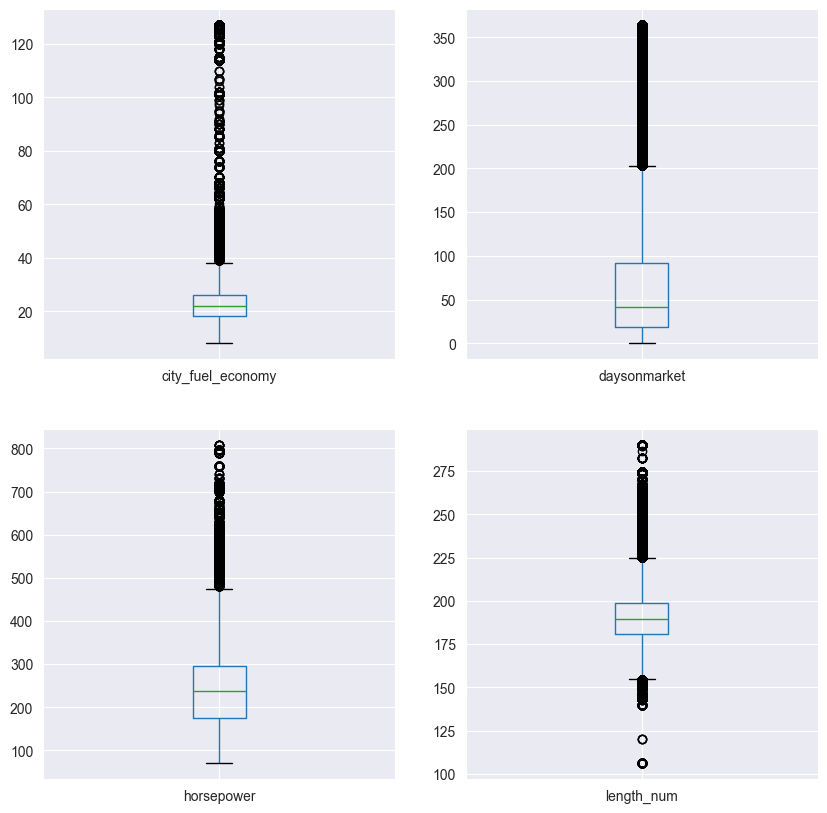

In [52]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train.boxplot(column="city_fuel_economy", ax=axes[0, 0])
df_train.boxplot(column="daysonmarket", ax=axes[0, 1])
df_train.boxplot(column="horsepower", ax=axes[1, 0])
df_train.boxplot(column="length_num", ax=axes[1, 1])

Les boxplots permettent de détecter de potentiel *outliers*, avec la règle de l'écart-interquartile.

Ici, dans les quatres boxplots, on voit des outliers cependant ça ne semble pas etre une erreur mais plutot des phénomènes rares mais plausibles. Traçons tous les boxplots.

<Axes: >

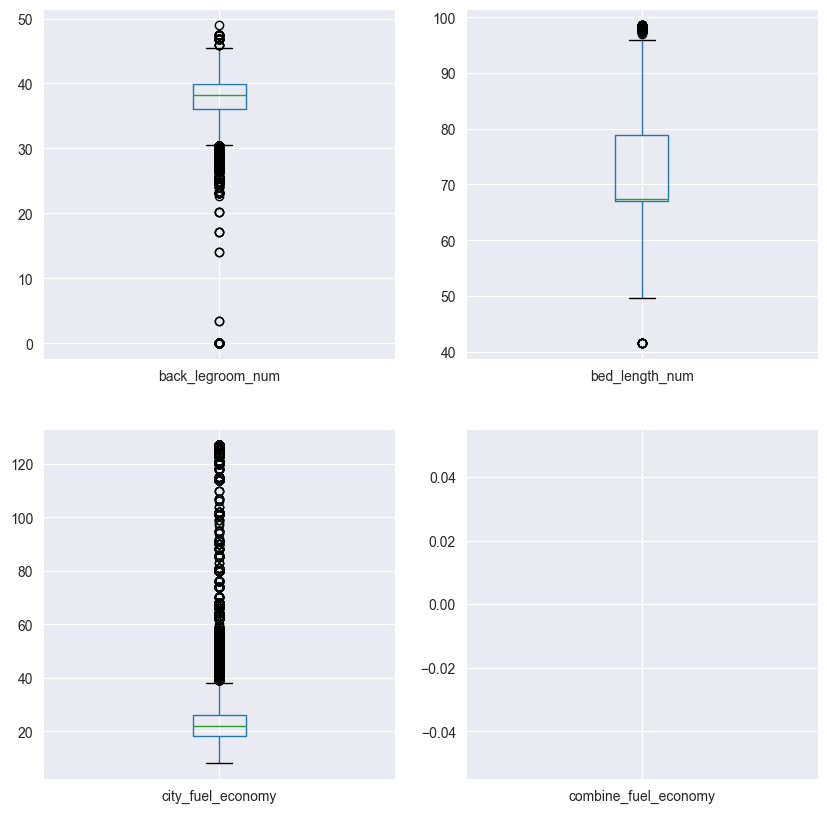

In [58]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train.boxplot(column="back_legroom_num", ax=axes[0, 0])
df_train.boxplot(column="bed_length_num", ax=axes[0, 1])
df_train.boxplot(column="city_fuel_economy", ax=axes[1, 0])
df_train.boxplot(column="combine_fuel_economy", ax=axes[1, 1])

<Axes: >

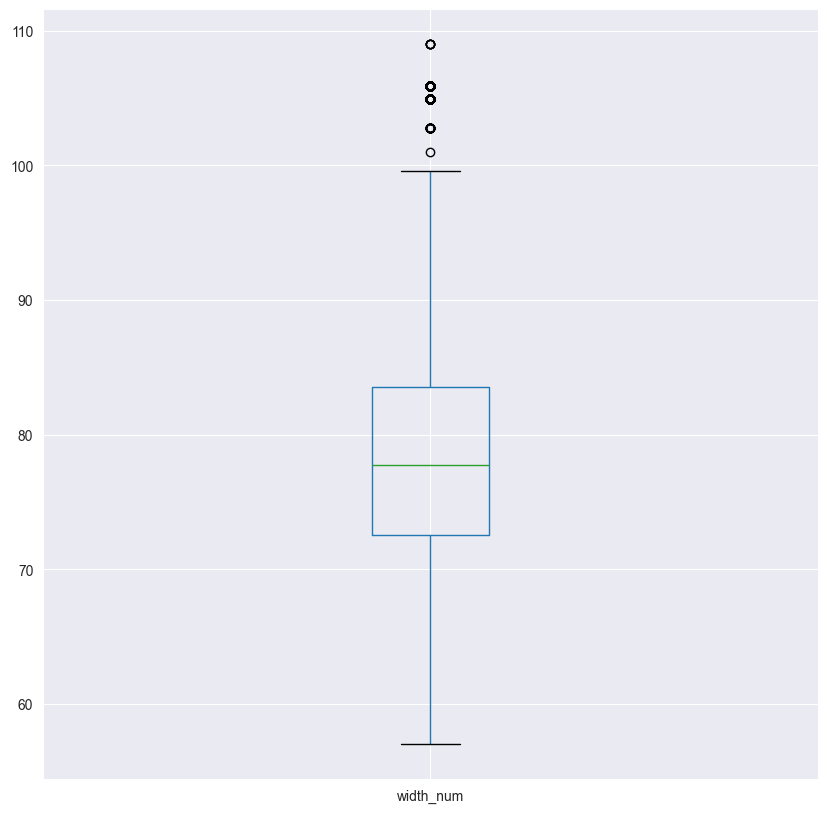

In [54]:
fig, axes=plt.subplots(nrows=1, ncols=1, figsize=(10, 10))

df_train.boxplot(column="width_num")

<Axes: >

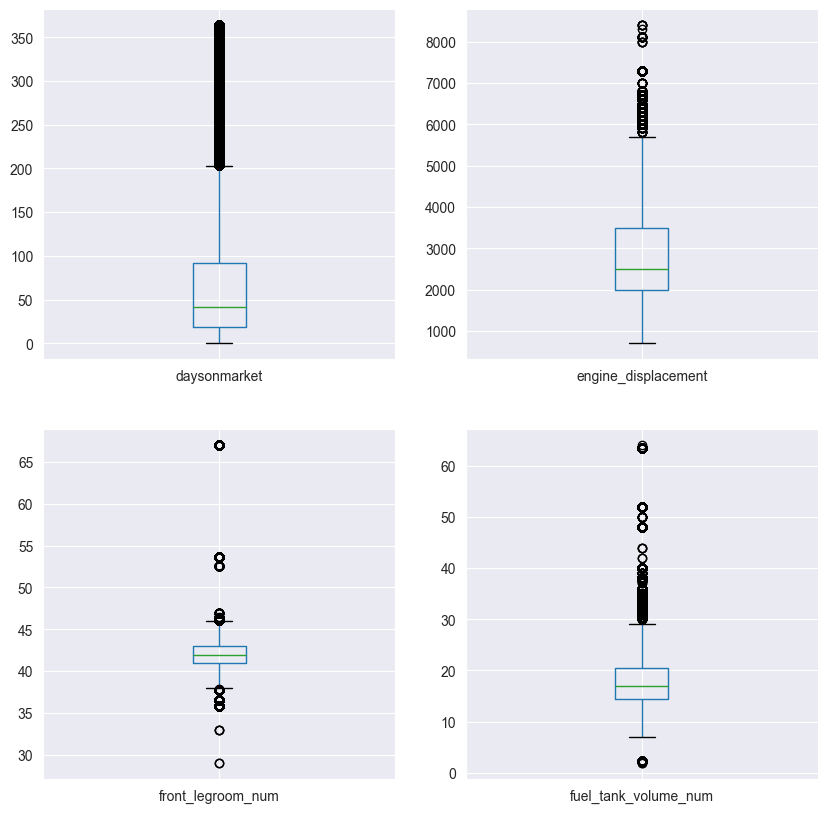

In [57]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train.boxplot(column="daysonmarket", ax=axes[0, 0])
df_train.boxplot(column="engine_displacement", ax=axes[0, 1])
df_train.boxplot(column="front_legroom_num", ax=axes[1, 0])
df_train.boxplot(column="fuel_tank_volume_num", ax=axes[1, 1])

<Axes: >

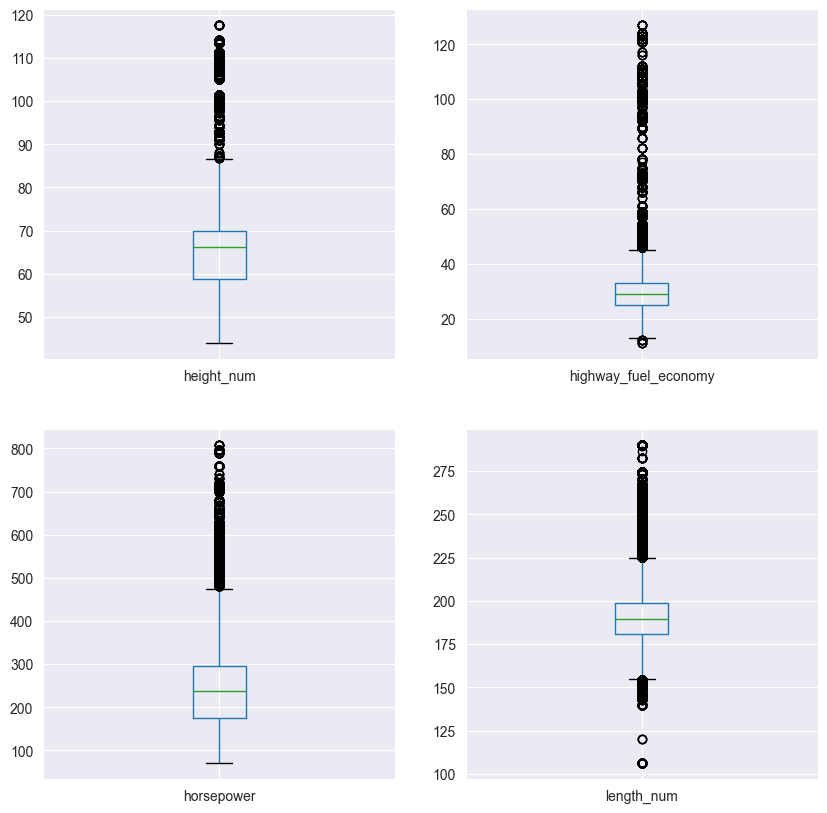

In [56]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train.boxplot(column="height_num", ax=axes[0, 0])
df_train.boxplot(column="highway_fuel_economy", ax=axes[0, 1])
df_train.boxplot(column="horsepower", ax=axes[1, 0])
df_train.boxplot(column="length_num", ax=axes[1, 1])

<Axes: >

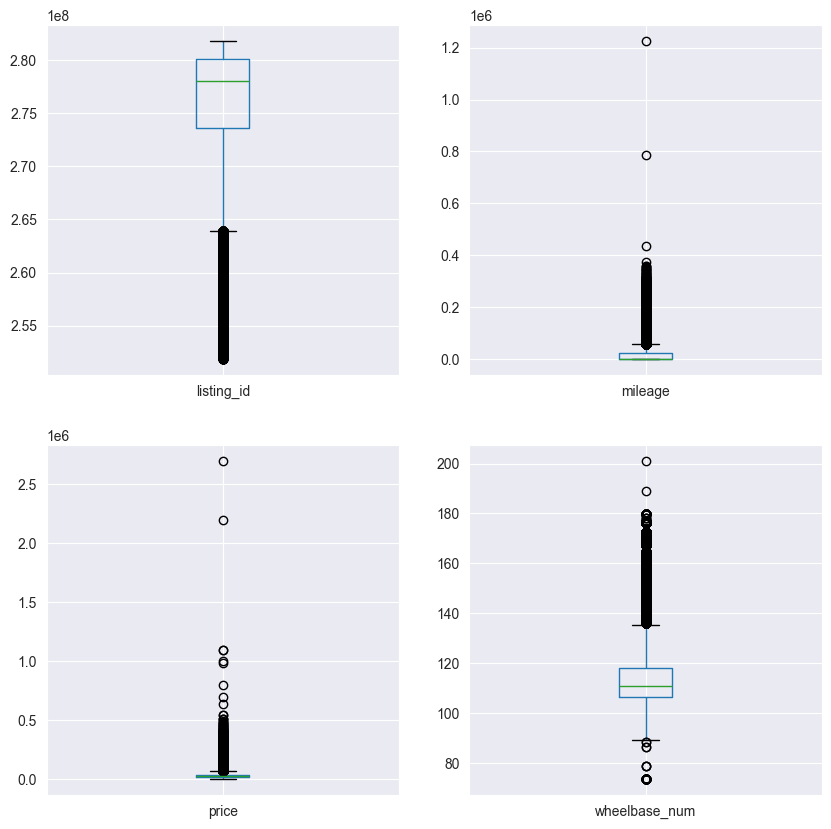

In [55]:
fig, axes=plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train.boxplot(column="listing_id", ax=axes[0, 0])
df_train.boxplot(column="mileage", ax=axes[0, 1])
df_train.boxplot(column="price", ax=axes[1, 0])
df_train.boxplot(column="wheelbase_num", ax=axes[1, 1])

### Variables catégorielles

<Axes: xlabel='fleet'>

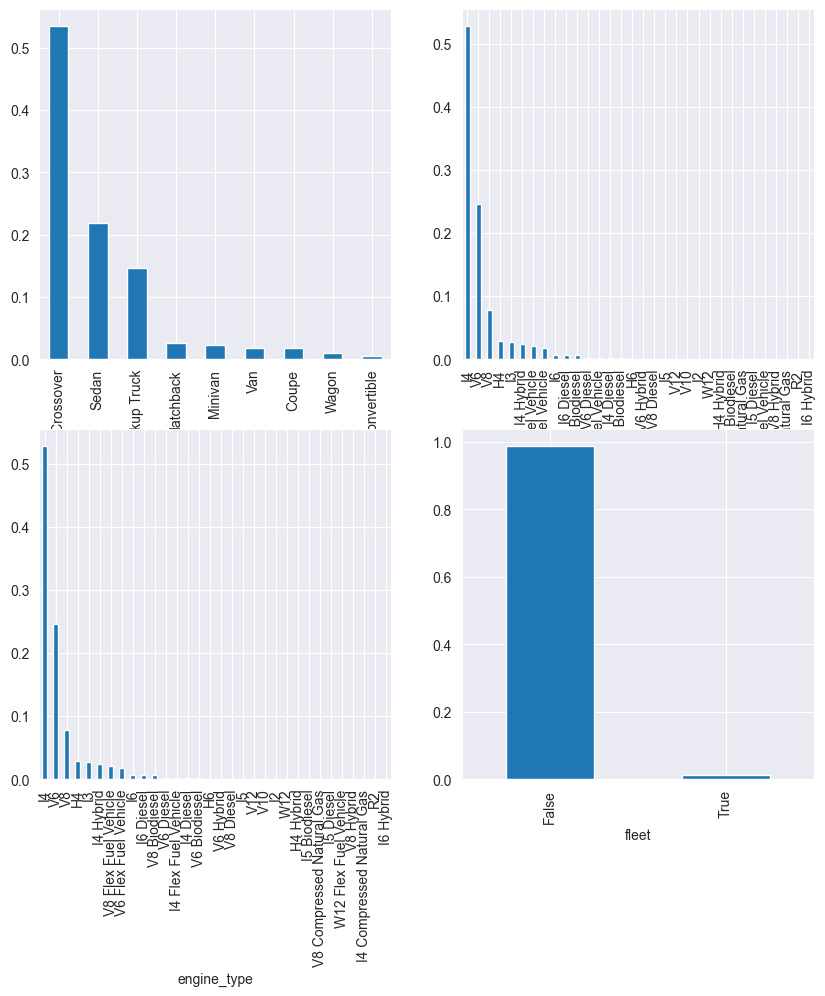

In [59]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train['body_type'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0])
df_train['engine_cylinders'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,1])
df_train['engine_type'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,0])
df_train['fleet'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,1])

<Axes: xlabel='is_new'>

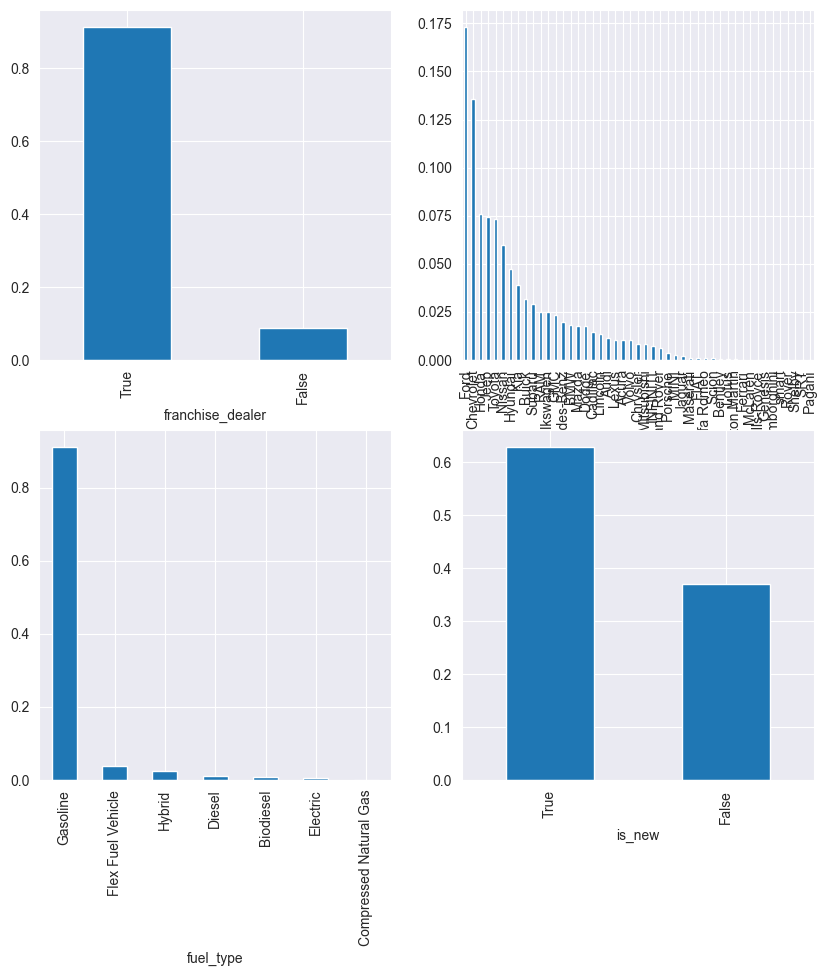

In [60]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train['franchise_dealer'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0])
df_train['franchise_make'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,1])
df_train['fuel_type'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,0])
df_train['is_new'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,1])

<Axes: xlabel='maximum_seating'>

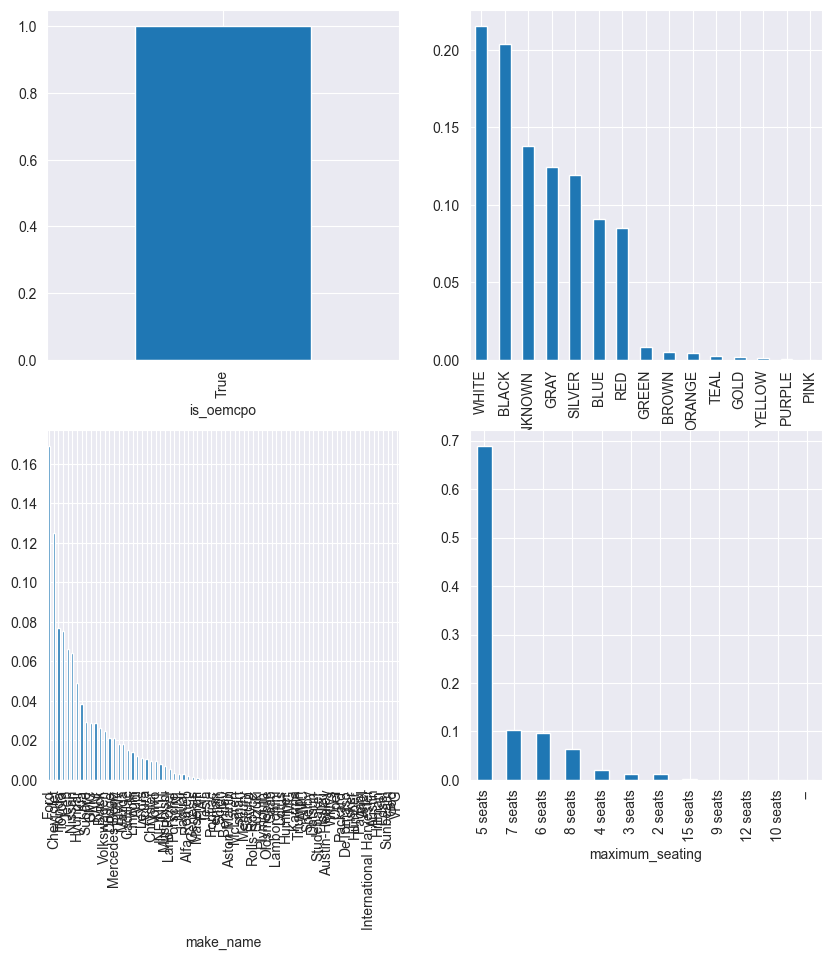

In [73]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train['is_oemcpo'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0])
df_train['listing_color'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,1])
df_train['make_name'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,0])
df_train['maximum_seating'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,1])

In [74]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

df_train['model_name'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,0])
df_train['sp_name'].value_counts(normalize=True).plot(kind='bar', ax=axes[0,1])
df_train['transmission'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,0])
df_train['trim_name'].value_counts(normalize=True).plot(kind='bar', ax=axes[1,1])

<Axes: xlabel='trim_name'>

Error in callback <function _draw_all_if_interactive at 0x1360a5220> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x4015d0040> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

<Axes: xlabel='is_oemcpo'>

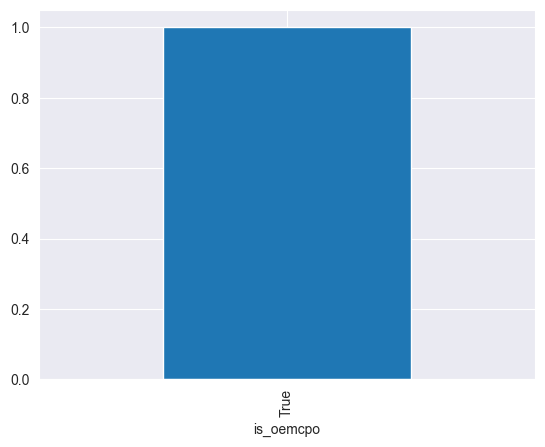

In [70]:
df_train['wheel_system'].value_counts(normalize=True).plot(kind='bar')

<Axes: xlabel='wheel_system_display'>

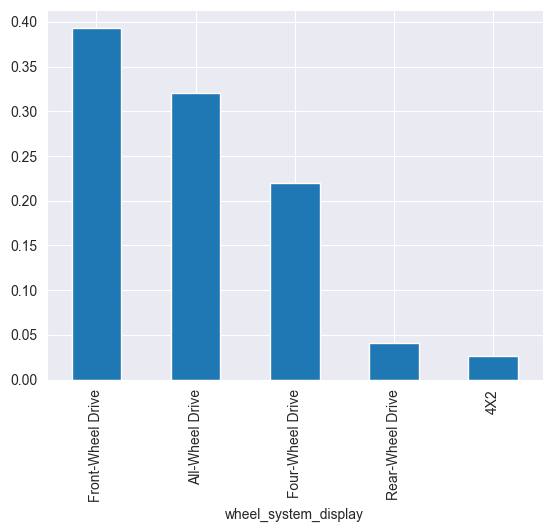

In [71]:
df_train['wheel_system_display'].value_counts(normalize=True).plot(kind='bar')

Les diagrammes en baton permettent de visualiser les différentes modalités des variables catégorielles, ainsi que leur répartition dans l'échantillon :

- la majorité des voitures étaient des `Front-Wheel Drive`;
- la majorité des passagers sont montés au même port (Southampton) ;
- la majorité des passagers étaient en classe 3, la moins chère.

### Statistiques bivariées

Les statistiques bivariées permettent de comprendre la structure des données, i.e. comment les différentes variables intéragissent entre eux. Dans notre cas, nous sommes particulièrement intéressés de voir comment la variable à prédire (`price`) est corrélée aux différentes variables à notre disposition. Cette étape doit permettre de **définir les variables pertinentes à inclure dans notre modélisation**.

### Séléction de variable

Le but est de trouvé les meilleurs variables pour expliquer le prix `price`. Pour cela il existe plusieurs méthodes, notamment les statistiques bivarié évoqué au dessus, étudier les corrélations, l'ANOVA...



### Corrélation

<Axes: >

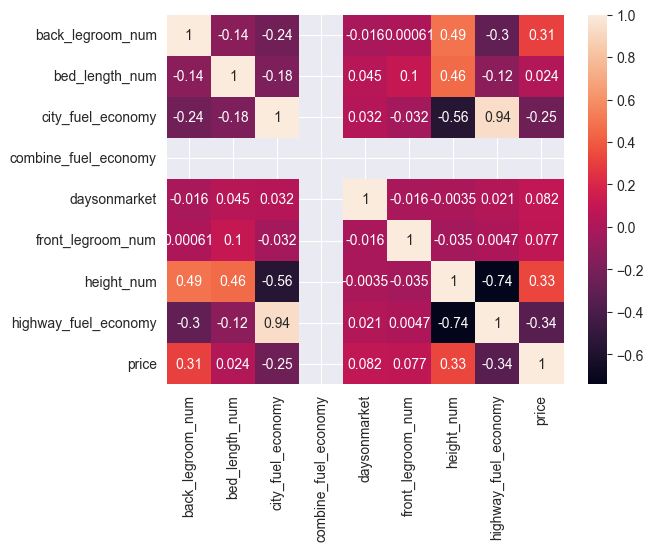

In [110]:
num_var1=["back_legroom_num", "bed_length_num", "city_fuel_economy", "combine_fuel_economy", "daysonmarket","front_legroom_num","height_num", "highway_fuel_economy","price"]

df_train[num_var].corr()
sns.heatmap(df_train[num_var1].corr(), annot=True)

<Axes: >

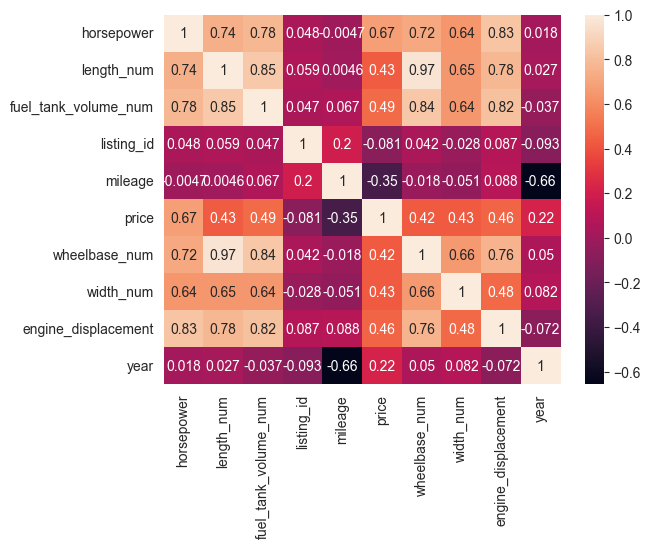

In [111]:
num_var2=["horsepower", "length_num","fuel_tank_volume_num", "listing_id", "mileage", "price", "wheelbase_num", "width_num","engine_displacement", "year"]
df_train[num_var].corr()
sns.heatmap(df_train[num_var2].corr(), annot=True)

## Préparation des données

Suite a l'exploration statistique des données, on a pu avoir quelques intuitions notamment sur comment traiter les anomalies présente ainsi que les variables a exclure et celle a conserver. Traitons cela.

### Supression des variables non-pertinentes

On peut supprimer un certain nombres de variables non-pertinentes pour notre application:

- `vin` : cette variable est simplement un identifiant individuel, elle n'est pas utile pour l'entraînement du modèle ;
- `back_legroom`: cette variable est mal codé, on la recodé en numérique;
- `bed_length` : idem;
- `combine_fuel_economy`: La majorité des valeurs de cette variables sont manquantes, elle n'est donc pas exploitable;
- `width` : cette variable est mal codé, on la recodé en numérique;
- `bed_length_num` : La majorité des valeurs de cette variables sont manquantes, elle n'est donc pas exploitable;



In [112]:
df_train

,vin,back_legroom,bed_length,body_type,city_fuel_economy,combine_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,engine_type,...,width,year,back_legroom_num,bed_length_num,front_legroom_num,height_num,length_num,wheelbase_num,width_num,fuel_tank_volume_num
53223,1GNSKAKC5KR408631,39 in,NaN,SUV / Crossover,NaN,NaN,13,V8,5300.0,V8,...,80.5 in,2019,39.0,NaN,45.3,74.4,204.0,116.0,80.5,26.0
161217,JTMA1RFV5LD531197,37.8 in,NaN,SUV / Crossover,25.0,NaN,11,I4,2500.0,I4,...,73 in,2020,37.8,NaN,41.0,67.2,180.9,105.9,73.0,14.5
661143,1C4RJFAG3LC437190,38.6 in,NaN,SUV / Crossover,18.0,NaN,4,V6,3600.0,V6,...,84.8 in,2020,38.6,NaN,40.3,69.3,189.8,114.7,84.8,24.6
114956,2T1BURHE4HC896404,41.4 in,NaN,Sedan,28.0,NaN,21,I4,1800.0,I4,...,69.9 in,2017,41.4,NaN,42.3,57.3,183.1,106.3,69.9,13.2
341648,3GNCJPSB7LL302496,35.7 in,NaN,SUV / Crossover,24.0,NaN,61,I4,1400.0,I4,...,69.9 in,2020,35.7,NaN,40.8,66.3,167.6,100.6,69.9,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846716,1C6HJTFG8LL189089,38.3 in,60.3 in,Pickup Truck,17.0,NaN,159,V6,3600.0,V6,...,73.8 in,2020,38.3,60.3,41.2,75.0,218.0,137.3,73.8,22.0
599350,3GCUKSEJ5JG301949,40.9 in,69.3 in,Pickup Truck,NaN,NaN,14,V8,6200.0,V8,...,80 in,2018,40.9,69.3,45.3,74.0,230.0,143.5,80.0,26.0
655237,3N1CN8DV3LL901571,31 in,NaN,Sedan,32.0,NaN,16,I4,1600.0,I4,...,68.5 in,2020,31.0,NaN,44.5,57.3,177.0,103.1,68.5,10.8
370219,1N4AA6AP7HC429846,34.2 in,NaN,Sedan,21.0,NaN,30,V6,3500.0,V6,...,73.2 in,2017,34.2,NaN,45.0,56.5,192.8,109.3,73.2,18.0


In [129]:
cols_to_drop=['vin','back_legroom','bed_length','combine_fuel_economy','width','bed_length_num','fleet','is_oemcpo','engine_cylinders','front_legroom','fuel_tank_volume','wheelbase','height','listed_date','listing_id','major_options','power','torque','transmission_display','trimId','trim_name','wheel_system_display','length',]
df_train2=df_train.drop(columns=cols_to_drop)

In [130]:
df_train2.head()

,body_type,city_fuel_economy,daysonmarket,engine_displacement,engine_type,franchise_dealer,franchise_make,fuel_type,highway_fuel_economy,horsepower,...,transmission,wheel_system,year,back_legroom_num,front_legroom_num,height_num,length_num,wheelbase_num,width_num,fuel_tank_volume_num
53223,SUV / Crossover,NaN,13,5300.0,V8,True,Chevrolet,Gasoline,NaN,355.0,...,A,4WD,2019,39.0,45.3,74.4,204.0,116.0,80.5,26.0
161217,SUV / Crossover,25.0,11,2500.0,I4,True,Toyota,Gasoline,33.0,203.0,...,A,AWD,2020,37.8,41.0,67.2,180.9,105.9,73.0,14.5
661143,SUV / Crossover,18.0,4,3600.0,V6,True,Jeep,Gasoline,25.0,295.0,...,A,4WD,2020,38.6,40.3,69.3,189.8,114.7,84.8,24.6
114956,Sedan,28.0,21,1800.0,I4,True,Toyota,Gasoline,36.0,132.0,...,CVT,FWD,2017,41.4,42.3,57.3,183.1,106.3,69.9,13.2
341648,SUV / Crossover,24.0,61,1400.0,I4,True,Chevrolet,Gasoline,29.0,138.0,...,A,AWD,2020,35.7,40.8,66.3,167.6,100.6,69.9,14.0


In [131]:
df_train2.info()

<class 'pandas.DataFrame'>
Index: 725731 entries, 53223 to 10967
Data columns (total 28 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   body_type             721996 non-null  str    
 1   city_fuel_economy     614491 non-null  float64
 2   daysonmarket          725731 non-null  int64  
 3   engine_displacement   687240 non-null  float64
 4   engine_type           705427 non-null  str    
 5   franchise_dealer      725731 non-null  bool   
 6   franchise_make        661530 non-null  str    
 7   fuel_type             709126 non-null  str    
 8   highway_fuel_economy  614491 non-null  float64
 9   horsepower            687240 non-null  float64
 10  is_new                725731 non-null  bool   
 11  listing_color         725731 non-null  str    
 12  make_name             725731 non-null  str    
 13  maximum_seating       692165 non-null  str    
 14  mileage               688347 non-null  float64
 15  model_name   

Désormais il nous reste 28 colonnes potentiellement pertinente, essayont de réduire encore avec les corrélations par exemple.

In [139]:
num_var=['city_fuel_economy','daysonmarket','engine_displacement','franchise_dealer','highway_fuel_economy','horsepower','is_new','mileage','year','price',]
sns.heatmap(df_train[num_var].corr(), annot=True)

,city_fuel_economy,daysonmarket,engine_displacement,franchise_dealer,highway_fuel_economy,horsepower,is_new,mileage,year,price
city_fuel_economy,1.000000,0.032211,-0.644959,0.027162,0.937690,-0.679808,0.079103,-0.092534,0.090802,-0.254027
daysonmarket,0.032211,1.000000,-0.086303,0.081639,0.020628,-0.048136,0.282991,-0.198282,0.095373,0.081980
engine_displacement,-0.644959,-0.086303,1.000000,-0.029548,-0.659615,0.828980,-0.051797,0.088185,-0.072317,0.457042
franchise_dealer,0.027162,0.081639,-0.029548,1.000000,0.008697,0.012796,0.399178,-0.456347,0.411185,0.185424
highway_fuel_economy,0.937690,0.020628,-0.659615,0.008697,1.000000,-0.705388,0.038930,-0.069302,0.062566,-0.337133
horsepower,-0.679808,-0.048136,0.828980,0.012796,-0.705388,1.000000,-0.015718,-0.004654,0.018411,0.674741
is_new,0.079103,0.282991,-0.051797,0.399178,0.038930,-0.015718,1.000000,-0.674169,0.523185,0.287733
mileage,-0.092534,-0.198282,0.088185,-0.456347,-0.069302,-0.004654,-0.674169,1.000000,-0.656561,-0.349975
year,0.090802,0.095373,-0.072317,0.411185,0.062566,0.018411,0.523185,-0.656561,1.000000,0.222408
price,-0.254027,0.081980,0.457042,0.185424,-0.337133,0.674741,0.287733,-0.349975,0.222408,1.000000


- On vois que city_fuel_economy et highway_fuel_economy sont très corrélé. Ainsi on supprime la variable qui est moins corrélé au prix i.e. city_fuel_economy
- horsepower est très corrélé a engine_displacement->On supprime engine_displacement
- horsepower est très corrélé a highway_fuel_economy->On supprime highway_fuel_economy

In [140]:
num_var=['daysonmarket','franchise_dealer','horsepower','is_new','mileage','year','back_legroom_num','front_legroom_num','height_num','length_num','wheelbase_num','width_num','fuel_tank_volume_num','price']
df_train[num_var].corr()

,daysonmarket,franchise_dealer,horsepower,is_new,mileage,year,back_legroom_num,front_legroom_num,height_num,length_num,wheelbase_num,width_num,fuel_tank_volume_num,price
daysonmarket,1.000000,0.081639,-0.048136,0.282991,-0.198282,0.095373,-0.015915,-0.015764,-0.003499,-0.059335,-0.041811,0.027811,-0.047301,0.081980
franchise_dealer,0.081639,1.000000,0.012796,0.399178,-0.456347,0.411185,0.080361,0.006154,0.054370,0.024584,0.033319,0.044886,-0.012331,0.185424
horsepower,-0.048136,0.012796,1.000000,-0.015718,-0.004654,0.018411,0.347647,0.219970,0.512542,0.744973,0.720787,0.640473,0.779015,0.674741
is_new,0.282991,0.399178,-0.015718,1.000000,-0.674169,0.523185,0.118442,-0.039965,0.092182,0.030845,0.052636,0.067227,-0.019383,0.287733
mileage,-0.198282,-0.456347,-0.004654,-0.674169,1.000000,-0.656561,-0.085324,0.013284,-0.022486,0.004585,-0.017882,-0.051189,0.066961,-0.349975
year,0.095373,0.411185,0.018411,0.523185,-0.656561,1.000000,0.128733,-0.010409,0.079481,0.026603,0.049924,0.081626,-0.036833,0.222408
back_legroom_num,-0.015915,0.080361,0.347647,0.118442,-0.085324,0.128733,1.000000,0.000606,0.488839,0.450714,0.430503,0.369646,0.411869,0.307156
front_legroom_num,-0.015764,0.006154,0.219970,-0.039965,0.013284,-0.010409,0.000606,1.000000,-0.034548,0.309402,0.271637,0.194475,0.184573,0.077480
height_num,-0.003499,0.054370,0.512542,0.092182,-0.022486,0.079481,0.488839,-0.034548,1.000000,0.667356,0.704021,0.583275,0.705276,0.328201
length_num,-0.059335,0.024584,0.744973,0.030845,0.004585,0.026603,0.450714,0.309402,0.667356,1.000000,0.966360,0.645434,0.847214,0.432179


- length_num et horsepower très corrélé->On supprime length_num
- height_num et wheelbase_num très corrélé->On supprime height_num
- length_num et horsepower très corrélé->On supprime length_num
- wheelbase_num très corrélé a horsepower-> On supprime wheelbase_num
- fuel_tant_volume_num très corrélé a horsepower->On supprime fuel_tant_volume_num

In [148]:
cols_to_drop=['length_num','height_num','wheelbase_num','fuel_tank_volume_num','engine_displacement','city_fuel_economy','highway_fuel_economy']
df_train_prepro=df_train2.drop(columns=cols_to_drop)

In [178]:
df_train_prepro.info()

<class 'pandas.DataFrame'>
Index: 725731 entries, 53223 to 10967
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   body_type          725731 non-null  str    
 1   daysonmarket       725731 non-null  int64  
 2   engine_type        725731 non-null  str    
 3   franchise_dealer   725731 non-null  bool   
 4   franchise_make     725731 non-null  str    
 5   fuel_type          725731 non-null  str    
 6   horsepower         725731 non-null  float64
 7   is_new             725731 non-null  bool   
 8   listing_color      725731 non-null  str    
 9   make_name          725731 non-null  str    
 10  maximum_seating    725731 non-null  str    
 11  mileage            725731 non-null  float64
 12  model_name         725731 non-null  str    
 13  price              725731 non-null  float64
 14  sp_name            725731 non-null  str    
 15  transmission       725731 non-null  str    
 16  wheel_system   

Désormais, il nous reste donc 20 variables potentiellement pertinentes, on va à présent traiter les valeurs manquantes.

### Traitement des valeurs manquantes

Cette fois, on va éviter au maximum la perte de données d'entraînement en **imputant les valeurs manquantes** :
- pour les variables numériques, on impute la **valeur médiane ou la valeur moyenne** de l'échantillon ;
- pour les variables catégorielles, on impute le **mode**, i.e. la modalité la plus fréquente dans l'échantillon.

Notons qu'on aurait pu réaliser une imputation plus fine, en calculant par exemple la médiane ou le mode parmi les individus du même sexe ou de la même tranche d'âge. Néanmoins, l'imputation par groupes ou par plus proches voisins n'est pas implémentée dans `scikit-learn`, et nécessiterait donc des adaptations importantes du code.

In [151]:
# Imputation de body_type par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
body_type_array = df_train_prepro["body_type"].values[:, np.newaxis]
df_train_prepro["body_type"] = imp.fit_transform(body_type_array).ravel()

In [156]:
# Imputation de engine_type par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
engine_type_array = df_train_prepro["engine_type"].values[:, np.newaxis]
df_train_prepro["engine_type"] = imp.fit_transform(engine_type_array).ravel()

In [160]:
# Imputation de franchise_make par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
franchise_make_array = df_train_prepro["franchise_make"].values[:, np.newaxis]
df_train_prepro["franchise_make"] = imp.fit_transform(franchise_make_array).ravel()

In [162]:
# Imputation de fuel_type par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
fuel_type_array = df_train_prepro["fuel_type"].values[:, np.newaxis]
df_train_prepro["fuel_type"] = imp.fit_transform(fuel_type_array).ravel()

In [164]:
# Imputation d'horsepower par la médiane
imp = SimpleImputer(missing_values=np.nan, strategy='median')
horsepower_array = df_train_prepro["horsepower"].values[:, np.newaxis]
df_train_prepro["horsepower"] = imp.fit_transform(horsepower_array).ravel()

In [166]:
# Imputation de maximum_seating par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
maximum_seating_array = df_train_prepro["maximum_seating"].values[:, np.newaxis]
df_train_prepro["maximum_seating"] = imp.fit_transform(maximum_seating_array).ravel()

In [168]:
# Imputation de mileage par la médiane
imp = SimpleImputer(missing_values=np.nan, strategy='median')
mileage_array = df_train_prepro["mileage"].values[:, np.newaxis]
df_train_prepro["mileage"] = imp.fit_transform(mileage_array).ravel()

In [171]:
# Imputation de transmission par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
transmission_array = df_train_prepro["transmission"].values[:, np.newaxis]
df_train_prepro["transmission"] = imp.fit_transform(transmission_array).ravel()

In [173]:
# Imputation de wheel_system par le mode
imp = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
wheel_system_array = df_train_prepro["wheel_system"].values[:, np.newaxis]
df_train_prepro["wheel_system"] = imp.fit_transform(wheel_system_array).ravel()

In [177]:
# Imputation de back_legroom_num par la médiane
imp = SimpleImputer(missing_values=np.nan, strategy='median')
back_legroom_num_array = df_train_prepro["back_legroom_num"].values[:, np.newaxis]
df_train_prepro["back_legroom_num"] = imp.fit_transform(back_legroom_num_array).ravel()

In [176]:
# Imputation de front_legroom_num par la médiane
imp = SimpleImputer(missing_values=np.nan, strategy='median')
front_legroom_num_array = df_train_prepro["front_legroom_num"].values[:, np.newaxis]
df_train_prepro["front_legroom_num"] = imp.fit_transform(front_legroom_num_array).ravel()

In [175]:
# Imputation de width_num par la médiane
imp = SimpleImputer(missing_values=np.nan, strategy='median')
width_num_array = df_train_prepro["width_num"].values[:, np.newaxis]
df_train_prepro["width_num"] = imp.fit_transform(width_num_array).ravel()

On a ainsi traité toutes les variables manquantes. On a donc un dataframe complet.

# Feature engineering



Le feature engineering renvoie au fait de créer de nouvelles variables à l'aide des variables déja présente qui seront généralement plus informatives et donc plus pertinentes pour la classification.



Par exemple, on peut déterminer l'age de la voiture qui seras plus pertinent que la variable year en effetuant la différence entre l'année actuel et l'année de sorti la voiture.

In [181]:
current_year = pd.Timestamp.now().year #Année actuelle
df_train_prepro['car_age'] = current_year - df_train_prepro['year']
df_train_prepro.drop(columns=['year'], inplace=True)

In [185]:
df_train_prepro

,body_type,daysonmarket,engine_type,franchise_dealer,franchise_make,fuel_type,horsepower,is_new,listing_color,make_name,...,mileage,model_name,price,sp_name,transmission,wheel_system,back_legroom_num,front_legroom_num,width_num,car_age
53223,SUV / Crossover,13,V8,True,Chevrolet,Gasoline,355.0,False,BLACK,Chevrolet,...,24519.0,Tahoe,43800.0,Feldman Chevrolet of Novi,A,4WD,39.0,45.3,80.5,7
161217,SUV / Crossover,11,I4,True,Toyota,Gasoline,203.0,True,UNKNOWN,Toyota,...,18.0,RAV4,33869.0,Rochester Toyota,A,AWD,37.8,41.0,73.0,6
661143,SUV / Crossover,4,V6,True,Jeep,Gasoline,295.0,True,BLACK,Jeep,...,12.0,Grand Cherokee,35275.0,Schlossmann Dodge Chrysler Jeep Ram,A,4WD,38.6,40.3,84.8,6
114956,Sedan,21,I4,True,Toyota,Gasoline,132.0,False,BLUE,Toyota,...,19536.0,Corolla,17728.0,Hartford Toyota Super Store,CVT,FWD,41.4,42.3,69.9,9
341648,SUV / Crossover,61,I4,True,Chevrolet,Gasoline,138.0,True,BLACK,Chevrolet,...,2.0,Trax,24765.0,Redbank Chevrolet,A,AWD,35.7,40.8,69.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
846716,Pickup Truck,159,V6,True,Jeep,Gasoline,285.0,True,WHITE,Jeep,...,12.0,Gladiator,44509.0,Thunder Chrysler Dodge Jeep Ram,A,4WD,38.3,41.2,73.8,6
599350,Pickup Truck,14,V8,True,Chevrolet,Gasoline,420.0,False,UNKNOWN,Chevrolet,...,25082.0,Silverado 1500,46433.0,Jim Wernig Chevrolet,A,4WD,40.9,45.3,80.0,8
655237,Sedan,16,I4,True,Nissan,Gasoline,122.0,True,UNKNOWN,Nissan,...,0.0,Versa,16599.0,Dick Smith Nissan of St. Andrews,CVT,FWD,31.0,44.5,68.5,6
370219,Sedan,30,V6,True,Acura,Gasoline,300.0,False,BLACK,Nissan,...,32185.0,Maxima,23995.0,McGrath Acura of Westmont,CVT,FWD,34.2,45.0,73.2,9


Back_legroom_num et front_legroom_num peuvent etre compacté en une variable moyenne

In [191]:
df_train_prepro['mean_legroom_num']=(df_train_prepro['back_legroom_num']+df_train_prepro['front_legroom_num'])/2
df_train_prepro.drop(columns=['back_legroom_num','front_legroom_num'], inplace=True)

In [195]:
df_train_prepro.head()

,body_type,daysonmarket,engine_type,franchise_dealer,franchise_make,fuel_type,horsepower,is_new,listing_color,make_name,maximum_seating,mileage,model_name,price,sp_name,transmission,wheel_system,width_num,car_age,mean_legroom_num
53223,SUV / Crossover,13,V8,True,Chevrolet,Gasoline,355.0,False,BLACK,Chevrolet,9 seats,24519.0,Tahoe,43800.0,Feldman Chevrolet of Novi,A,4WD,80.5,7,42.15
161217,SUV / Crossover,11,I4,True,Toyota,Gasoline,203.0,True,UNKNOWN,Toyota,5 seats,18.0,RAV4,33869.0,Rochester Toyota,A,AWD,73.0,6,39.40
661143,SUV / Crossover,4,V6,True,Jeep,Gasoline,295.0,True,BLACK,Jeep,5 seats,12.0,Grand Cherokee,35275.0,Schlossmann Dodge Chrysler Jeep Ram,A,4WD,84.8,6,39.45
114956,Sedan,21,I4,True,Toyota,Gasoline,132.0,False,BLUE,Toyota,5 seats,19536.0,Corolla,17728.0,Hartford Toyota Super Store,CVT,FWD,69.9,9,41.85
341648,SUV / Crossover,61,I4,True,Chevrolet,Gasoline,138.0,True,BLACK,Chevrolet,5 seats,2.0,Trax,24765.0,Redbank Chevrolet,A,AWD,69.9,6,38.25


### Traitement des variables numériques

Si les variables numériques ont des fortes différences d'échelle, cela peut poser des problèmes numériques lors du processus d'optimisation des modèles de Machine Learning ce qui va augmenter le temps d'entrainement voire empêcher la convergence dans certains cas.

Une solution à cela est de standardiser les variables numériques dans une même échelle. On peut donc utiliser une standardisation, c'est à dire une transformation centrée-réduite des variables numériques.

In [197]:
scaler=StandardScaler()
df_train_prepro[['daysonmarket','horsepower','mileage','price','width_num','car_age','mean_legroom_num']]=scaler.fit_transform(df_train_prepro[['daysonmarket','horsepower','mileage','price','width_num','car_age','mean_legroom_num']].values)

In [198]:
df_train_prepro.head()

,body_type,daysonmarket,engine_type,franchise_dealer,franchise_make,fuel_type,horsepower,is_new,listing_color,make_name,maximum_seating,mileage,model_name,price,sp_name,transmission,wheel_system,width_num,car_age,mean_legroom_num
53223,SUV / Crossover,-0.737221,V8,True,Chevrolet,Gasoline,1.287671,False,BLACK,Chevrolet,9 seats,0.336284,Tahoe,0.612449,Feldman Chevrolet of Novi,A,4WD,0.255538,-0.061872,1.266960
161217,SUV / Crossover,-0.760385,I4,True,Toyota,Gasoline,-0.468275,True,UNKNOWN,Toyota,5 seats,-0.519906,RAV4,0.061189,Rochester Toyota,A,AWD,-0.740011,-0.371656,-0.475676
661143,SUV / Crossover,-0.841460,V6,True,Jeep,Gasoline,0.594535,True,BLACK,Jeep,5 seats,-0.520115,Grand Cherokee,0.139235,Schlossmann Dodge Chrysler Jeep Ram,A,4WD,0.826319,-0.371656,-0.443992
114956,Sedan,-0.644564,I4,True,Toyota,Gasoline,-1.288487,False,BLUE,Toyota,5 seats,0.162152,Corolla,-0.834781,Hartford Toyota Super Store,CVT,FWD,-1.151504,0.557695,1.076854
341648,SUV / Crossover,-0.181280,I4,True,Chevrolet,Gasoline,-1.219173,True,BLACK,Chevrolet,5 seats,-0.520465,Trax,-0.444164,Redbank Chevrolet,A,AWD,-1.151504,-0.371656,-1.204415


In [200]:
df_train_prepro.drop(columns=['sp_name'], inplace=True) #Variable inutile

### Traitement des variables catégorielles

Un algorithme de Machine Learning ne sait traiter que des valeurs numériques mais pas du texte. On remarque que dans notre dataset, certaines variables catégorielles sont déja encodées au format numérique (`franchise_dealer`, `is_new`) par exemple, mais d'autres (`transmission`, `wheel_system`,`body_type`, `engine_type`, `franchise_make`, `fuel_type`, `listing_color`, `make_name`, `maximum_seating`, `model_name`) sont présentes sous forme de modalités textuelles qu'il faut donc encoder numériquement. La méthode d'encodage pertinente doit dépendre de la nature des modalités ainsi que du modèle de Mahine Learning utilisé pour l'entraînement :

- Pour les variables ordinales (avec ordre), il est préférable d'utiliser une encodage sous forme d'entiers. Dans notre cas on a `maximum_seating` comme variable ordinale.

- Pour les variables cardinales (l'ordre des modalités n'a pas de sens) il faudrait utiliser un encodage neutre comme le one-hot-encoding qui va générer des variables binaires (dummies) pour chaque modalité. Cet encodage est préférable pour les modèles linéaires.

In [209]:
#Conversion maximum_seating en entier
df_train_prepro['maximum_seating'] = (
    df_train_prepro['maximum_seating']
        .str.extract('(\d+)')      # extrait le nombre
        .astype(float)             # convertit en numérique
)

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/var/folders/mc/g9__gqz90s7dx6wyrgy5rfbw0000gn/T/ipykernel_29899/2005699822.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  .str.extract('(\d+)')      # extrait le nombre


AttributeError: Can only use .str accessor with string values, not floating

In [214]:
df_train_prepro['maximum_seating'].info()

<class 'pandas.Series'>
Index: 725731 entries, 53223 to 10967
Series name: maximum_seating
Non-Null Count   Dtype  
--------------   -----  
725632 non-null  float64
dtypes: float64(1)
memory usage: 11.1 MB


In [215]:
#Encodage maximum_seating : ordinal

encoder=OrdinalEncoder()
df_train_prepro['maximum_seating_encoded'] = encoder.fit_transform(df_train_prepro[['maximum_seating']])


In [219]:
df_train_prepro.drop(columns=['maximum_seating'], inplace=True)

### Encodage cardinal

In [220]:
df_train_prepro['body_type'].unique()

<StringArray>
['SUV / Crossover',           'Sedan',         'Minivan',    'Pickup Truck',
             'Van',           'Wagon',     'Convertible',       'Hatchback',
           'Coupe']
Length: 9, dtype: str

In [221]:
# One-Hot-Encoding pour body_type

df_train_prepro = pd.get_dummies(df_train_prepro, columns=["body_type"])
df_train_prepro.head()

,daysonmarket,engine_type,franchise_dealer,franchise_make,fuel_type,horsepower,is_new,listing_color,make_name,mileage,...,maximum_seating_encoded,body_type_Convertible,body_type_Coupe,body_type_Hatchback,body_type_Minivan,body_type_Pickup Truck,body_type_SUV / Crossover,body_type_Sedan,body_type_Van,body_type_Wagon
53223,-0.737221,V8,True,Chevrolet,Gasoline,1.287671,False,BLACK,Chevrolet,0.336284,...,7.0,False,False,False,False,False,True,False,False,False
161217,-0.760385,I4,True,Toyota,Gasoline,-0.468275,True,UNKNOWN,Toyota,-0.519906,...,3.0,False,False,False,False,False,True,False,False,False
661143,-0.841460,V6,True,Jeep,Gasoline,0.594535,True,BLACK,Jeep,-0.520115,...,3.0,False,False,False,False,False,True,False,False,False
114956,-0.644564,I4,True,Toyota,Gasoline,-1.288487,False,BLUE,Toyota,0.162152,...,3.0,False,False,False,False,False,False,True,False,False
341648,-0.181280,I4,True,Chevrolet,Gasoline,-1.219173,True,BLACK,Chevrolet,-0.520465,...,3.0,False,False,False,False,False,True,False,False,False


In [222]:
df_train_prepro['engine_type'].unique()

<StringArray>
[                       'V8',                        'I4',
                        'V6',                 'I4 Hybrid',
                 'I4 Diesel',      'V8 Flex Fuel Vehicle',
                        'H4',                        'I3',
                 'I6 Diesel',                        'I6',
      'V6 Flex Fuel Vehicle',              'V8 Biodiesel',
                 'V6 Diesel',                       'V10',
      'I4 Flex Fuel Vehicle',              'V6 Biodiesel',
                       'V12',                        'H6',
                 'V6 Hybrid',                        'I5',
                       'W12',                 'V8 Diesel',
                        'I2',                 'H4 Hybrid',
                 'V8 Hybrid',                 'I5 Diesel',
 'V8 Compressed Natural Gas',              'I5 Biodiesel',
     'W12 Flex Fuel Vehicle', 'I4 Compressed Natural Gas',
                 'I6 Hybrid',                        'R2']
Length: 32, dtype: str

Ici, il y'a 32 modalité, il faudrait regrouper les V6-V12... ensemble, les I5-I6... etc pour réduire les modalités et ensuite faire une One-Hot-Encoding.

In [223]:
df_train_prepro['franchise_make'].unique() # Idem, trop de modalité, il faudrait réduire

<StringArray>
[    'Chevrolet',        'Toyota',          'Jeep',         'Honda',
          'Ford',           'Kia',      'Chrysler',        'Nissan',
    'Volkswagen',        'Subaru',    'Land Rover',         'Buick',
       'Hyundai',           'RAM',           'GMC',         'Dodge',
           'BMW',      'INFINITI',         'Mazda',         'Volvo',
          'Audi',         'Acura',         'Lexus',       'Lincoln',
          'FIAT',      'Maserati', 'Mercedes-Benz',    'Mitsubishi',
          'MINI',   'Rolls-Royce',      'Cadillac',       'Genesis',
       'McLaren',       'Bentley',         'Scion',  'Aston Martin',
       'Porsche',        'Jaguar',    'Alfa Romeo',       'Ferrari',
   'Lamborghini',         'Lotus',         'smart',        'Shelby',
        'Pagani',         'Rover',           'SRT']
Length: 47, dtype: str

In [224]:
df_train_prepro['fuel_type'].unique() #7 modalité -> One-Hot-Encoding

<StringArray>
[              'Gasoline',                 'Hybrid',                 'Diesel',
      'Flex Fuel Vehicle',              'Biodiesel',               'Electric',
 'Compressed Natural Gas']
Length: 7, dtype: str

In [232]:
#One-Hot-Encoding fuel_type

df_train_prepro = pd.get_dummies(df_train_prepro, columns=["fuel_type"])
df_train_prepro.head()

,daysonmarket,engine_type,franchise_dealer,franchise_make,horsepower,is_new,listing_color,make_name,mileage,model_name,...,body_type_Sedan,body_type_Van,body_type_Wagon,fuel_type_Biodiesel,fuel_type_Compressed Natural Gas,fuel_type_Diesel,fuel_type_Electric,fuel_type_Flex Fuel Vehicle,fuel_type_Gasoline,fuel_type_Hybrid
53223,-0.737221,V8,True,Chevrolet,1.287671,False,BLACK,Chevrolet,0.336284,Tahoe,...,False,False,False,False,False,False,False,False,True,False
161217,-0.760385,I4,True,Toyota,-0.468275,True,UNKNOWN,Toyota,-0.519906,RAV4,...,False,False,False,False,False,False,False,False,True,False
661143,-0.841460,V6,True,Jeep,0.594535,True,BLACK,Jeep,-0.520115,Grand Cherokee,...,False,False,False,False,False,False,False,False,True,False
114956,-0.644564,I4,True,Toyota,-1.288487,False,BLUE,Toyota,0.162152,Corolla,...,True,False,False,False,False,False,False,False,True,False
341648,-0.181280,I4,True,Chevrolet,-1.219173,True,BLACK,Chevrolet,-0.520465,Trax,...,False,False,False,False,False,False,False,False,True,False


In [233]:
df_train_prepro.info()

<class 'pandas.DataFrame'>
Index: 725731 entries, 53223 to 10967
Data columns (total 33 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   daysonmarket                      725731 non-null  float64
 1   engine_type                       725731 non-null  str    
 2   franchise_dealer                  725731 non-null  bool   
 3   franchise_make                    725731 non-null  str    
 4   horsepower                        725731 non-null  float64
 5   is_new                            725731 non-null  bool   
 6   listing_color                     725731 non-null  str    
 7   make_name                         725731 non-null  str    
 8   mileage                           725731 non-null  float64
 9   model_name                        725731 non-null  str    
 10  price                             725731 non-null  float64
 11  transmission                      725731 non-null  str    
 12  w

In [235]:
df_train_prepro['listing_color'].unique()

<StringArray>
[  'BLACK', 'UNKNOWN',    'BLUE',  'SILVER',   'WHITE',    'GRAY',     'RED',
   'GREEN',  'ORANGE',    'GOLD',   'BROWN',  'YELLOW',    'TEAL',    'PINK',
  'PURPLE']
Length: 15, dtype: str

In [236]:
#One-Hot-Encoding listing_color

df_train_prepro = pd.get_dummies(df_train_prepro, columns=["listing_color"])

In [237]:
df_train_prepro['make_name'].unique() #Trop de modalité

<StringArray>
[              'Chevrolet',                  'Toyota',
                    'Jeep',                   'Honda',
                    'Ford',                     'Kia',
                'Chrysler',                  'Nissan',
              'Volkswagen',                     'GMC',
                   'Acura',                   'Buick',
                 'Hyundai',                     'RAM',
                  'Subaru',              'Alfa Romeo',
                 'Lincoln',                   'Dodge',
                     'BMW',                'INFINITI',
                   'Volvo',                    'Audi',
                   'Mazda',                   'Lexus',
              'Land Rover',                  'Jaguar',
                    'Opel',           'Mercedes-Benz',
                'Maserati',              'Mitsubishi',
                    'MINI',                    'FIAT',
                  'Suzuki',                'Cadillac',
                 'Genesis',                 'McLare

In [238]:
df_train_prepro['model_name'].unique() #Trop de modalité

<StringArray>
[                'Tahoe',                  'RAV4',        'Grand Cherokee',
               'Corolla',                  'Trax',               'Insight',
              'Explorer',                 'Forte',              'Pacifica',
         'Fusion Hybrid',
 ...
 'Murano CrossCabriolet',               'LaSalle',               'Model B',
       '599 GTB Fiorano',                'F12tdf',          'Milan Hybrid',
                    'TD',                   'LFA',              'Corniche',
                  'Stag']
Length: 1083, dtype: str

In [239]:
df_train_prepro.head()

,daysonmarket,engine_type,franchise_dealer,franchise_make,horsepower,is_new,make_name,mileage,model_name,price,...,listing_color_GREEN,listing_color_ORANGE,listing_color_PINK,listing_color_PURPLE,listing_color_RED,listing_color_SILVER,listing_color_TEAL,listing_color_UNKNOWN,listing_color_WHITE,listing_color_YELLOW
53223,-0.737221,V8,True,Chevrolet,1.287671,False,Chevrolet,0.336284,Tahoe,0.612449,...,False,False,False,False,False,False,False,False,False,False
161217,-0.760385,I4,True,Toyota,-0.468275,True,Toyota,-0.519906,RAV4,0.061189,...,False,False,False,False,False,False,False,True,False,False
661143,-0.841460,V6,True,Jeep,0.594535,True,Jeep,-0.520115,Grand Cherokee,0.139235,...,False,False,False,False,False,False,False,False,False,False
114956,-0.644564,I4,True,Toyota,-1.288487,False,Toyota,0.162152,Corolla,-0.834781,...,False,False,False,False,False,False,False,False,False,False
341648,-0.181280,I4,True,Chevrolet,-1.219173,True,Chevrolet,-0.520465,Trax,-0.444164,...,False,False,False,False,False,False,False,False,False,False


Ainsi, nous avons montré différents exemple d'encodage permettant ensuite l'entrainement du modèle.